<a href="https://colab.research.google.com/github/einar6969/st-gr4/blob/main/Forritunarverkefni_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stærðfræðigreining IV
## Forritunarverkefni
### Einar Skúli Zoega & Oddur Sigurðarson


In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d import Axes3D

## Fyrri þraut

In [ ]:
def varmadreifing(Lx, Ly, N, M, L, delta, P, K, H, ub):
    """
    Reiknar nálgunarlausn á hitadreifingunni í kæliplötu.ch

    Inntök:
      Lx     - vídd plötunnar í x (cm)
      Ly     - vídd plötunnar í y (cm)
      N      - fjöldi skrefa í x (netinu verður N+1 punktar)
      M      - fjöldi skrefa í y (netinu verður M+1 punktar)
      L      - lengd hitunarjaðarsvæðis á vinstri hlið (cm)
      delta  - þykkt plötunnar (cm)
      P      - varmaafl (W) sem berst inn um vinstri hliðina
      K      - varmaleiðni (W/(cm·°C))
      H      - útþenslustuðull burðarvarma (W/(cm·°C))
      ub     - umhverfishitastig (°C); lausnin u táknar hitamun (raunhitastig = u + ub)

    Úttök:
      Xnet, Ynet - 2D net (meshgrid) yfir x og y
      w         - 2D-fylki nálgunarlausnar (u-gildi, hitamun)
    """
    n = N + 1      # fjöldi punkta í x
    m = M + 1      # fjöldi punkta í y
    dx = Lx / N
    dy = Ly / M
    total_nodes = n * m

    # Reikna stuðla
    q = 2 * H / (delta * K)          # PDE stuðull, tengdur q = 2H/(δK)
    E = P / (L * delta * K)          # Neumann-skilyrði á hitunarjaðri
    F = H / K                        # Robin skilyrði (kæling)

    # Búum til netið
    x = np.linspace(0, Lx, n)
    y = np.linspace(0, Ly, m)
    Xnet, Ynet = np.meshgrid(x, y)

    # Hjálparfall til að reikna einstaka vísitölu
    def idx(j, k):
        return j + k * n

    # Byggjum sparse fylkið A og vigurinn b
    A = sp.lil_matrix((total_nodes, total_nodes))
    b = np.zeros(total_nodes)

    # Hjálparfall til að athuga hvort punktur á vinstri hliðin (j=0) liggi á hitunarjaðrinu
    def on_heating_boundary(k):
        y_val = k * dy
        return (y_val >= (Ly/2 - L/2)) and (y_val <= (Ly/2 + L/2))

    # Lausnarsmíð
    for k in range(m):
        for j in range(n):
            i = idx(j, k)

            # Innri punktar
            if (j != 0) and (j != N) and (k != 0) and (k != M):
                A[i, i] = 2/dx**2 + 2/dy**2 + q
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k-1)] = -1/dy**2
                A[i, idx(j, k+1)] = -1/dy**2

            # Vinstri hornpunktur neðst
            elif j == 0 and k == 0:
                if L == Lx:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dy)
                    b[i] = 2 * E / dx
                else:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j+1, k)] = -2/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Vinstri hornpunktur efst
            elif j == 0 and k == M:
                if L == Lx:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dy)
                    b[i] = 2 * E / dx
                else:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j+1, k)] = -2/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

            # Hægri hornpunktur neðst
            elif j == N and k == 0:
                A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j-1, k)] = -2/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Hægri hornpunktur efst
            elif j == N and k == M:
                A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j-1, k)] = -2/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

            # Vinstri jaðar (ekki horn)
            elif j == 0:
                if on_heating_boundary(k):
                    alpha = 0.0
                    gamma = E
                else:
                    alpha = -F
                    gamma = 0.0
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dx * alpha
                A[i, idx(j+1, k)] = -2/dx**2
                if k > 0:
                    A[i, idx(j, k-1)] = -1/dy**2
                if k < m-1:
                    A[i, idx(j, k+1)] = -1/dy**2
                b[i] = 2/dx * gamma

            # Hægri jaðar (ekki horn)
            elif j == N:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dx * alpha
                A[i, idx(j-1, k)] = -2/dx**2
                if k > 0:
                    A[i, idx(j, k-1)] = -1/dy**2
                if k < m-1:
                    A[i, idx(j, k+1)] = -1/dy**2

            # Neðri jaðar (ekki horn)
            elif k == 0:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dy * alpha
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Efri jaðar (ekki horn)
            elif k == M:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dy * alpha
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

    # Lausn línulega jöfnuhneppisins
    A_csr = A.tocsr()
    c = spla.spsolve(A_csr, b)

    # Endurformum lausnina
    w = c.reshape((m, n))
    return Xnet, Ynet, w

## Liður 1

In [ ]:
# Liður 1 - Hæsta hitastig
def max_temperature(Lx, Ly, N, M, L, delta, P, K, H, ub):
    """
    Reiknar hæsta raunhitastigið á kæliplötunni.

    Fallið kallar á varmadreifing(…) og bætir síðan umhverfishitastiginu ub við lausnina.

    Skilar:
      max_temp - hæsta hitastigið (°C)
    """
    Xnet, Ynet, w = varmadreifing(Lx, Ly, N, M, L, delta, P, K, H, ub)
    # Raunhitastig = hitamunur + umhverfishiti
    T = w + ub
    return np.max(T)

Hæsta hitastigið í kæliplötunni er: 164.27 °C


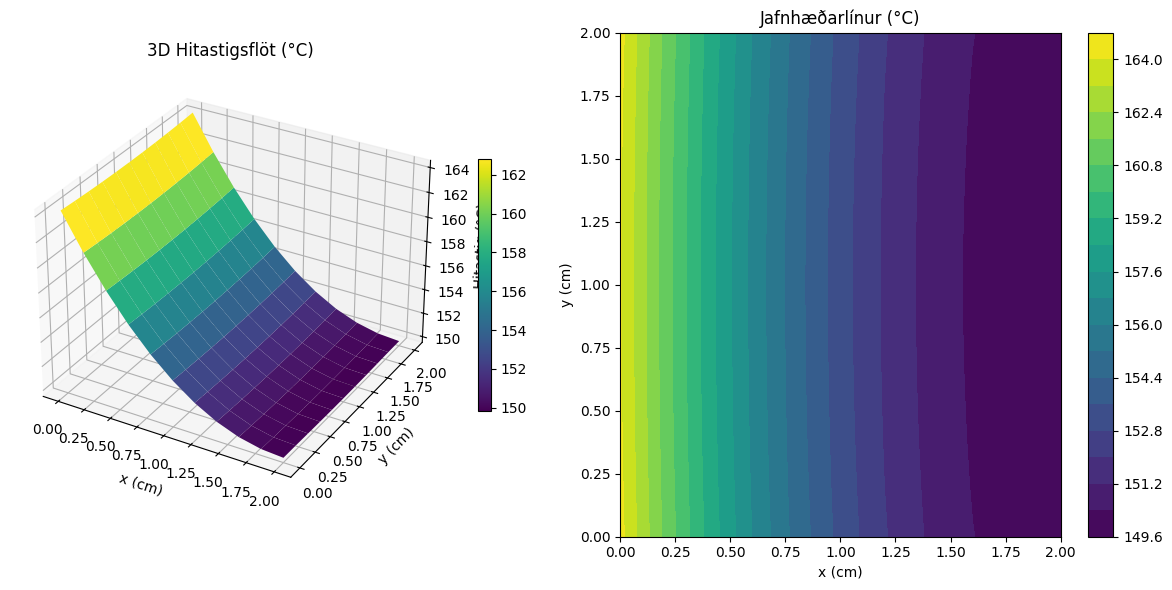

In [ ]:
# Liður 1 - Myndir
if __name__ == "__main__":
    # Gildi verkefnisins
    Lx, Ly, N, M = 2.0, 2.0, 10, 10
    L, delta, P = 2.0, 0.1, 5.0
    K, H, ub = 1.68, 0.005, 20.0

    Xnet, Ynet, w = varmadreifing(Lx, Ly, N, M, L, delta, P, K, H, ub)
    max_temp = max_temperature(Lx, Ly, N, M, L, delta, P, K, H, ub)
    print("Hæsta hitastigið í kæliplötunni er: {:.2f} °C".format(max_temp))

    # Teiknum niðurstöðu
    fig = plt.figure(figsize=(12,6))

    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(Xnet, Ynet, w + ub, cmap='viridis')
    ax1.set_title('3D Hitastigsflöt (°C)')
    ax1.set_xlabel('x (cm)')
    ax1.set_ylabel('y (cm)')
    ax1.set_zlabel('Hitastig (°C)')
    fig.colorbar(surf, ax=ax1, shrink=0.5)

    ax2 = fig.add_subplot(122)
    cs = ax2.contourf(Xnet, Ynet, w + ub, levels=20, cmap='viridis')
    ax2.set_title('Jafnhæðarlínur (°C)')
    ax2.set_xlabel('x (cm)')
    ax2.set_ylabel('y (cm)')
    fig.colorbar(cs, ax=ax2)

    plt.tight_layout()
    plt.show()


## Liður 2

Hæsta hitastigið í kæliplötunni er: 67.15 °C


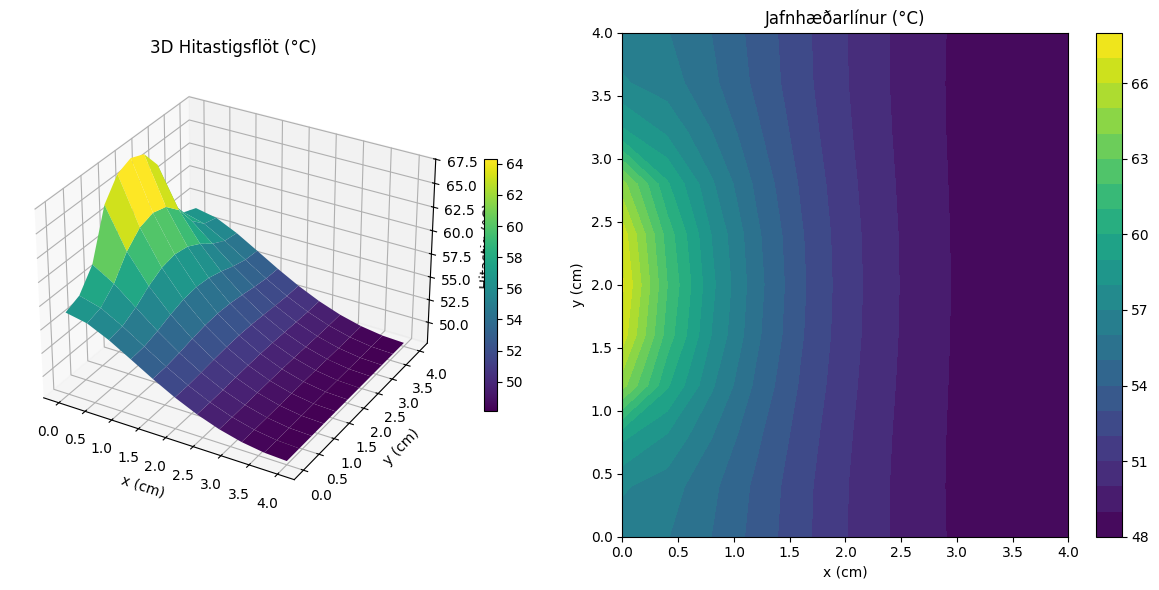

In [ ]:
# Liður 2 - Myndir
if __name__ == "__main__":
    # Gildi verkefnisins
    Lx, Ly, N, M = 4.0, 4.0, 10, 10
    L, delta, P = 2.0, 0.1, 5.0
    K, H, ub = 1.68, 0.005, 20.0

    Xnet, Ynet, w = varmadreifing(Lx, Ly, N, M, L, delta, P, K, H, ub)
    max_temp = max_temperature(Lx, Ly, N, M, L, delta, P, K, H, ub)
    print("Hæsta hitastigið í kæliplötunni er: {:.2f} °C".format(max_temp))

    # Teiknum niðurstöðu
    fig = plt.figure(figsize=(12,6))

    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(Xnet, Ynet, w + ub, cmap='viridis')
    ax1.set_title('3D Hitastigsflöt (°C)')
    ax1.set_xlabel('x (cm)')
    ax1.set_ylabel('y (cm)')
    ax1.set_zlabel('Hitastig (°C)')
    fig.colorbar(surf, ax=ax1, shrink=0.5)

    ax2 = fig.add_subplot(122)
    cs = ax2.contourf(Xnet, Ynet, w + ub, levels=20, cmap='viridis')
    ax2.set_title('Jafnhæðarlínur (°C)')
    ax2.set_xlabel('x (cm)')
    ax2.set_ylabel('y (cm)')
    fig.colorbar(cs, ax=ax2)

    plt.tight_layout()
    plt.show()

Grid size 5x5: Max Temperature = 58.11 °C
Grid size 10x10: Max Temperature = 67.15 °C
Grid size 15x15: Max Temperature = 69.74 °C
Grid size 20x20: Max Temperature = 71.10 °C
Grid size 30x30: Max Temperature = 67.33 °C
Grid size 40x40: Max Temperature = 69.26 °C
Grid size 50x50: Max Temperature = 67.36 °C
Grid size 60x60: Max Temperature = 68.64 °C
Grid size 70x70: Max Temperature = 67.37 °C
Grid size 80x80: Max Temperature = 68.33 °C
Grid size 90x90: Max Temperature = 67.37 °C
Grid size 100x100: Max Temperature = 68.14 °C
Grid size 150x150: Max Temperature = 67.38 °C
Grid size 200x200: Max Temperature = 67.76 °C


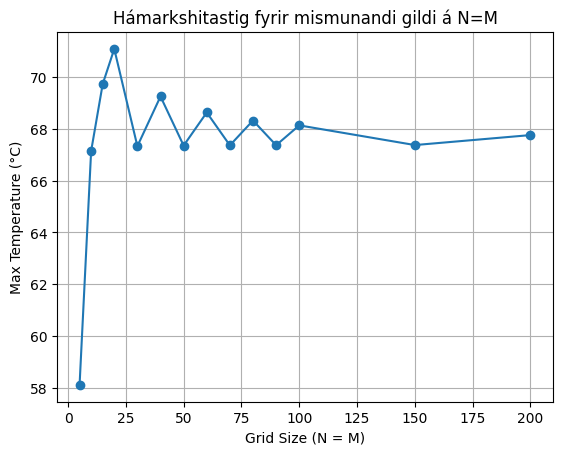

In [ ]:
def grid_convergence_study():
    """
    Prófar mismunandi netstærðir (N x M, með N = M) og reiknar hæsta hitastigið
    fyrir hverja uppsetningu. Graf teiknar breytinguna á hæsta hitastigi sem fall af netstærð.
    """
    # Gildi
    Lx = 4.0      # cm
    Ly = 4.0      # cm
    L  = 2.0      # lengd hitunarjaðarsvæðis (cm)
    delta = 0.1   # þykkt plötunnar (cm)
    P  = 5.0      # varmaafl (W)
    K  = 1.68     # W/(cm°C) (t.d. fyrir ál)
    H  = 0.005    # W/(cm°C) fyrir loftkælingu
    ub = 20.0     # umhverfishiti (°C)

    # Veljum mismunandi netstærðir (N = M)
    grid_sizes = [5, 10, 15, 20, 30, 40, 50, 60,70, 80, 90, 100, 150, 200]
    max_temps = []

    for grid in grid_sizes:
        # Reikna hæsta hitastigið fyrir hvern grid (notum fallið max_temperature)
        max_temp = max_temperature(Lx, Ly, grid, grid, L, delta, P, K, H, ub)
        max_temps.append(max_temp)
        print(f"Grid size {grid}x{grid}: Max Temperature = {max_temp:.2f} °C")

    # Teikna graf: max hitastig sem fall af netstærð
    plt.figure()
    plt.plot(grid_sizes, max_temps, marker='o', linestyle='-')
    plt.xlabel('Grid Size (N = M)')
    plt.ylabel('Max Temperature (°C)')
    plt.title('Hámarkshitastig fyrir mismunandi gildi á N=M')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    grid_convergence_study()


Prófanir fyrir 2×2 cm kæliplötu:
  Grid 10x10: Hæsta hitastig = 164.27 °C


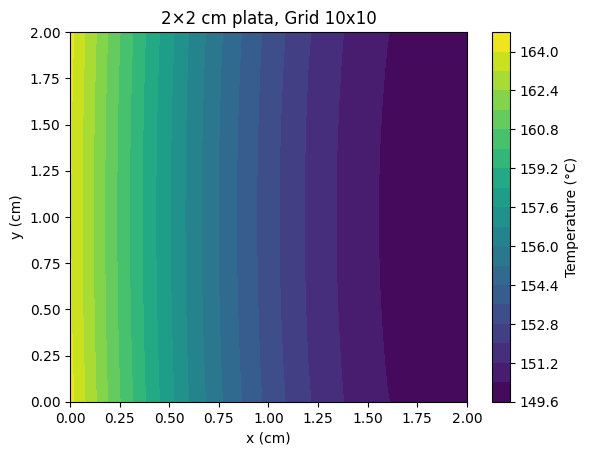

  Grid 20x20: Hæsta hitastig = 164.54 °C


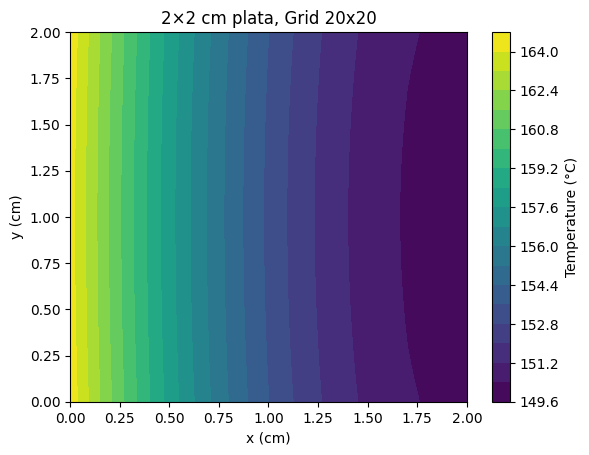


Prófanir fyrir 4×4 cm kæliplötu:
  Grid 20x20: Hæsta hitastig = 71.10 °C


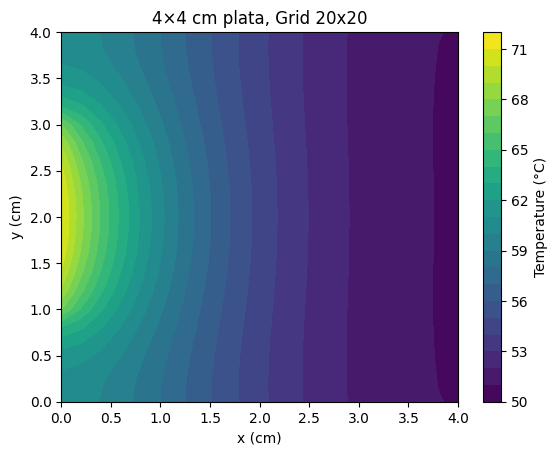

  Grid 40x40: Hæsta hitastig = 69.26 °C


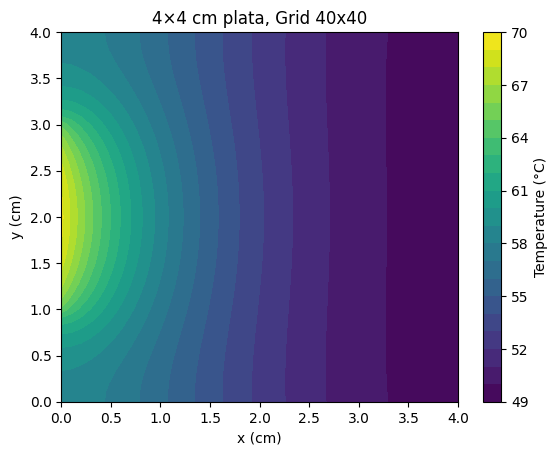

In [ ]:
def test_plate_scaling():
    """
    Prófar tvær stækkanir á kæliplötunni:
      1. Upphafleg (2×2 cm)
      2. Stækkuð (4×4 cm)

    Fyrir hverja plötustærð keyrir þetta forrit lausnina fyrir nokkra
    netstærðir (N×M) og prentar út hæsta hitastig og teiknar jafnhæðargraf af hitadreifingunni.
    """

    # Gildin
    L = 2.0       # lengd hitunarjaðarsvæðis (cm) (heldum L óbreytt)
    delta = 0.1   # plötutýkkni (cm)
    P = 5.0       # varmaafl (W)
    K = 1.68      # varmaleiðni (W/(cm°C)) fyrir ál
    H = 0.005     # útþenslustuðull (W/(cm°C)) fyrir loftkælingu
    ub = 20.0     # umhverfishiti (°C)

    # 1. Upphafleg plata: 2×2 cm
    Lx_2, Ly_2 = 2.0, 2.0
    # Prófunargildi fyrir grid upplausn (N = M)
    grid_sizes_2 = [10, 20]

    print("Prófanir fyrir 2×2 cm kæliplötu:")
    for grid in grid_sizes_2:
        Xnet, Ynet, w = varmadreifing(Lx_2, Ly_2, grid, grid, L, delta, P, K, H, ub)
        T = w + ub   # Raunhitastig (u + umhverfishiti)
        max_temp = np.max(T)
        print(f"  Grid {grid}x{grid}: Hæsta hitastig = {max_temp:.2f} °C")

        plt.figure()
        plt.contourf(Xnet, Ynet, T, levels=20, cmap='viridis')
        plt.title(f"2×2 cm plata, Grid {grid}x{grid}")
        plt.xlabel("x (cm)")
        plt.ylabel("y (cm)")
        plt.colorbar(label="Temperature (°C)")
        plt.show()

    # 2. Stækkuð plata: 4×4 cm
    Lx_4, Ly_4 = 4.0, 4.0
    # Til að tryggja nægilega nákvæmni á stærri plötu notum við hærri grid upplausn
    grid_sizes_4 = [20, 40]

    print("\nPrófanir fyrir 4×4 cm kæliplötu:")
    for grid in grid_sizes_4:
        Xnet, Ynet, w = varmadreifing(Lx_4, Ly_4, grid, grid, L, delta, P, K, H, ub)
        T = w + ub   # Raunhitastig
        max_temp = np.max(T)
        print(f"  Grid {grid}x{grid}: Hæsta hitastig = {max_temp:.2f} °C")

        plt.figure()
        plt.contourf(Xnet, Ynet, T, levels=20, cmap='viridis')
        plt.title(f"4×4 cm plata, Grid {grid}x{grid}")
        plt.xlabel("x (cm)")
        plt.ylabel("y (cm)")
        plt.colorbar(label="Temperature (°C)")
        plt.show()

if __name__ == "__main__":
    test_plate_scaling()


## Liður 3

In [ ]:
# Liður 3
def hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub, tol=0.01, max_iter=100):
    """
    Finnur hámarksvarmaaflið P þannig að hæsta hitastigið (u + ub) á kæliplötunni sé nálægt T_target (°C)
    án þess að fara yfir það.

    Inntök:
      T_target - markhitastig (°C), t.d. 80 °C
      Lx, Ly   - vídd plötunnar í x og y (cm)
      N, M     - netstærðir (N+1 x M+1 punktar)
      L        - lengd hitunarjaðarsvæðis á vinstri hlið (cm)
      delta    - þykkt plötunnar (cm)
      P_init   - upphafs ágildi á varmaafli (W)
      K        - varmaleiðni (W/(cm·°C))
      H        - utþenslustuðull burðarvarma (W/(cm·°C))
      ub       - umhverfishitastig (°C)
      tol      - þol fyrir samleitni í P (W)
      max_iter - hámarksfjöldi ítrana

    Skilar:
      P_optimal - P (W) sem gefur hæsta hitastigið nálægt T_target
      Tmax_optimal - hæsta hitastigið við P_optimal (°C)
    """
    P_low = 0.0
    P_high = P_init
    # Hækkum P_high þar til hæsta hitastigið verður undir T_target.
    while max_temperature(Lx, Ly, N, M, L, delta, P_high, K, H, ub) < T_target:
        P_high *= 2
        print(f"Aukin P_high: {P_high:.2f} W")

    iter_count = 0
    while iter_count < max_iter and (P_high - P_low) > tol:
        P_mid = (P_low + P_high) / 2.0
        Tmax_mid = max_temperature(Lx, Ly, N, M, L, delta, P_mid, K, H, ub)
        print(f"Iter {iter_count:3d}: P_mid = {P_mid:.3f} W, Tmax = {Tmax_mid:.2f} °C")
        if Tmax_mid <= T_target:
            P_low = P_mid  # P_mid er viðunandi, hægt að reyna hærra P
        else:
            P_high = P_mid  # P_mid er of hátt
        iter_count += 1

    P_optimal = (P_low + P_high) / 2.0
    Tmax_optimal = max_temperature(Lx, Ly, N, M, L, delta, P_optimal, K, H, ub)
    return P_optimal, Tmax_optimal

# Dæmi um notkun:
if __name__ == "__main__":
    # Föst gildi (sama og áður):
    Lx = 4.0      # cm
    Ly = 4.0      # cm
    N = 100        # notum nokkur fínari net (N = M)
    M = 100
    L = 2.0       # cm
    delta = 0.1   # cm
    P_init = 5.0  # upphafs gildi á P (W)
    K = 1.68      # W/(cm°C) fyrir ál
    H = 0.005     # W/(cm°C) fyrir loftkælingu
    ub = 20.0     # °C
    T_target = 79.9 # °C – markhitastig

    P_opt, Tmax_opt = hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub)
    print(f"\nHámarksaflið sem tryggir að hitastigið sé undir {T_target}°C er: {P_opt:.2f} W")
    print(f"Við þetta afl verður hæsta hitastigið: {Tmax_opt:.2f} °C")


Aukin P_high: 10.00 W
Iter   0: P_mid = 5.000 W, Tmax = 68.14 °C
Iter   1: P_mid = 7.500 W, Tmax = 92.21 °C
Iter   2: P_mid = 6.250 W, Tmax = 80.17 °C
Iter   3: P_mid = 5.625 W, Tmax = 74.16 °C
Iter   4: P_mid = 5.938 W, Tmax = 77.17 °C
Iter   5: P_mid = 6.094 W, Tmax = 78.67 °C
Iter   6: P_mid = 6.172 W, Tmax = 79.42 °C
Iter   7: P_mid = 6.211 W, Tmax = 79.80 °C
Iter   8: P_mid = 6.230 W, Tmax = 79.99 °C
Iter   9: P_mid = 6.221 W, Tmax = 79.89 °C

Hámarksaflið sem tryggir að hitastigið sé undir 79.9°C er: 6.23 W
Við þetta afl verður hæsta hitastigið: 79.94 °C


## Liður 4

In [ ]:
# Liður 4
def hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub, tol=0.01, max_iter=100):
    """
    Finnur hámarksvarmaaflið P þannig að hæsta hitastigið (u + ub) á kæliplötunni sé nálægt T_target (°C)
    án þess að fara yfir það.

    Inntök:
      T_target - markhitastig (°C), t.d. 80 °C
      Lx, Ly   - vídd plötunnar í x og y (cm)
      N, M     - netstærðir (N+1 x M+1 punktar)
      L        - lengd hitunarjaðarsvæðis á vinstri hlið (cm)
      delta    - þykkt plötunnar (cm)
      P_init   - upphafs ágildi á varmaafli (W)
      K        - varmaleiðni (W/(cm·°C))
      H        - utþenslustuðull burðarvarma (W/(cm·°C))
      ub       - umhverfishitastig (°C)
      tol      - þol fyrir samleitni í P (W)
      max_iter - hámarksfjöldi ítrana

    Skilar:
      P_optimal - P (W) sem gefur hæsta hitastigið nálægt T_target
      Tmax_optimal - hæsta hitastigið við P_optimal (°C)
    """
    P_low = 0.0
    P_high = P_init
    # Hækkum P_high þar til hæsta hitastigið verður undir T_target.
    while max_temperature(Lx, Ly, N, M, L, delta, P_high, K, H, ub) < T_target:
        P_high *= 2
        print(f"Aukin P_high: {P_high:.2f} W")

    iter_count = 0
    while iter_count < max_iter and (P_high - P_low) > tol:
        P_mid = (P_low + P_high) / 2.0
        Tmax_mid = max_temperature(Lx, Ly, N, M, L, delta, P_mid, K, H, ub)
        print(f"Iter {iter_count:3d}: P_mid = {P_mid:.3f} W, Tmax = {Tmax_mid:.2f} °C")
        if Tmax_mid <= T_target:
            P_low = P_mid  # P_mid er viðunandi, hægt að reyna hærra P
        else:
            P_high = P_mid  # P_mid er of hátt
        iter_count += 1

    P_optimal = (P_low + P_high) / 2.0
    Tmax_optimal = max_temperature(Lx, Ly, N, M, L, delta, P_optimal, K, H, ub)
    return P_optimal, Tmax_optimal

# Dæmi um notkun:
if __name__ == "__main__":
    # Föst gildi (sama og áður):
    Lx = 4.0      # cm
    Ly = 4.0      # cm
    N = 100        # notum nokkur fínari net (N = M)
    M = 100
    L = 2.0       # cm
    delta = 0.1   # cm
    P_init = 5.0  # upphafs gildi á P (W)
    K = 3.85      # W/(cm°C) fyrir kopar
    H = 0.005     # W/(cm°C) fyrir loftkælingu
    ub = 20.0     # °C
    T_target = 79.9 # °C – markhitastig

    P_opt, Tmax_opt = hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub)
    print(f"\nHámarksaflið sem tryggir að hitastigið sé undir {T_target}°C er: {P_opt:.2f} W")
    print(f"Við þetta afl verður hæsta hitastigið: {Tmax_opt:.2f} °C")


Aukin P_high: 10.00 W
Iter   0: P_mid = 5.000 W, Tmax = 59.93 °C
Iter   1: P_mid = 7.500 W, Tmax = 79.90 °C
Iter   2: P_mid = 6.250 W, Tmax = 69.92 °C
Iter   3: P_mid = 6.875 W, Tmax = 74.91 °C
Iter   4: P_mid = 7.188 W, Tmax = 77.41 °C
Iter   5: P_mid = 7.344 W, Tmax = 78.65 °C
Iter   6: P_mid = 7.422 W, Tmax = 79.28 °C
Iter   7: P_mid = 7.461 W, Tmax = 79.59 °C
Iter   8: P_mid = 7.480 W, Tmax = 79.75 °C
Iter   9: P_mid = 7.490 W, Tmax = 79.82 °C

Hámarksaflið sem tryggir að hitastigið sé undir 79.9°C er: 7.50 W
Við þetta afl verður hæsta hitastigið: 79.86 °C


## Liður 5

In [ ]:
# Liður 5 - Ál
def hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub, tol=0.01, max_iter=100):
    """
    Finnur hámarksvarmaaflið P þannig að hæsta hitastigið (u + ub) á kæliplötunni sé nálægt T_target (°C)
    án þess að fara yfir það.

    Inntök:
      T_target - markhitastig (°C), t.d. 80 °C
      Lx, Ly   - vídd plötunnar í x og y (cm)
      N, M     - netstærðir (N+1 x M+1 punktar)
      L        - lengd hitunarjaðarsvæðis á vinstri hlið (cm)
      delta    - þykkt plötunnar (cm)
      P_init   - upphafs ágildi á varmaafli (W)
      K        - varmaleiðni (W/(cm·°C))
      H        - utþenslustuðull burðarvarma (W/(cm·°C))
      ub       - umhverfishitastig (°C)
      tol      - þol fyrir samleitni í P (W)
      max_iter - hámarksfjöldi ítrana

    Skilar:
      P_optimal - P (W) sem gefur hæsta hitastigið nálægt T_target
      Tmax_optimal - hæsta hitastigið við P_optimal (°C)
    """
    P_low = 0.0
    P_high = P_init
    # Hækkum P_high þar til hæsta hitastigið verður undir T_target.
    while max_temperature(Lx, Ly, N, M, L, delta, P_high, K, H, ub) < T_target:
        P_high *= 2
        print(f"Aukin P_high: {P_high:.2f} W")

    iter_count = 0
    while iter_count < max_iter and (P_high - P_low) > tol:
        P_mid = (P_low + P_high) / 2.0
        Tmax_mid = max_temperature(Lx, Ly, N, M, L, delta, P_mid, K, H, ub)
        print(f"Iter {iter_count:3d}: P_mid = {P_mid:.3f} W, Tmax = {Tmax_mid:.2f} °C")
        if Tmax_mid <= T_target:
            P_low = P_mid  # P_mid er viðunandi, hægt að reyna hærra P
        else:
            P_high = P_mid  # P_mid er of hátt
        iter_count += 1

    P_optimal = (P_low + P_high) / 2.0
    Tmax_optimal = max_temperature(Lx, Ly, N, M, L, delta, P_optimal, K, H, ub)
    return P_optimal, Tmax_optimal

# Dæmi um notkun:
if __name__ == "__main__":
    # Föst gildi (sama og áður):
    Lx = 4.0      # cm
    Ly = 4.0      # cm
    N = 100        # notum nokkur fínari net (N = M)
    M = 100
    L = 2.0       # cm
    delta = 0.1   # cm
    P_init = 5.0  # upphafs gildi á P (W)
    K = 1.68      # W/(cm°C) fyrir ál
    H = 0.1     # W/(cm°C) fyrir loftkælingu
    ub = 20.0     # °C
    T_target = 79.9 # °C – markhitastig

    P_opt, Tmax_opt = hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub)
    print(f"\nHámarksaflið sem tryggir að hitastigið sé undir {T_target}°C er: {P_opt:.2f} W")
    print(f"Við þetta afl verður hæsta hitastigið: {Tmax_opt:.2f} °C")


Aukin P_high: 10.00 W
Aukin P_high: 20.00 W
Aukin P_high: 40.00 W
Iter   0: P_mid = 20.000 W, Tmax = 65.65 °C
Iter   1: P_mid = 30.000 W, Tmax = 88.47 °C
Iter   2: P_mid = 25.000 W, Tmax = 77.06 °C
Iter   3: P_mid = 27.500 W, Tmax = 82.76 °C
Iter   4: P_mid = 26.250 W, Tmax = 79.91 °C
Iter   5: P_mid = 25.625 W, Tmax = 78.48 °C
Iter   6: P_mid = 25.938 W, Tmax = 79.20 °C
Iter   7: P_mid = 26.094 W, Tmax = 79.55 °C
Iter   8: P_mid = 26.172 W, Tmax = 79.73 °C
Iter   9: P_mid = 26.211 W, Tmax = 79.82 °C
Iter  10: P_mid = 26.230 W, Tmax = 79.87 °C
Iter  11: P_mid = 26.240 W, Tmax = 79.89 °C

Hámarksaflið sem tryggir að hitastigið sé undir 79.9°C er: 26.25 W
Við þetta afl verður hæsta hitastigið: 79.90 °C


In [ ]:
# Liður 5 - Kopar
def hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub, tol=0.01, max_iter=100):
    """
    Finnur hámarksvarmaaflið P þannig að hæsta hitastigið (u + ub) á kæliplötunni sé nálægt T_target (°C)
    án þess að fara yfir það.

    Inntök:
      T_target - markhitastig (°C), t.d. 80 °C
      Lx, Ly   - vídd plötunnar í x og y (cm)
      N, M     - netstærðir (N+1 x M+1 punktar)
      L        - lengd hitunarjaðarsvæðis á vinstri hlið (cm)
      delta    - þykkt plötunnar (cm)
      P_init   - upphafs ágildi á varmaafli (W)
      K        - varmaleiðni (W/(cm·°C))
      H        - utþenslustuðull burðarvarma (W/(cm·°C))
      ub       - umhverfishitastig (°C)
      tol      - þol fyrir samleitni í P (W)
      max_iter - hámarksfjöldi ítrana

    Skilar:
      P_optimal - P (W) sem gefur hæsta hitastigið nálægt T_target
      Tmax_optimal - hæsta hitastigið við P_optimal (°C)
    """
    P_low = 0.0
    P_high = P_init
    # Hækkum P_high þar til hæsta hitastigið verður undir T_target.
    while max_temperature(Lx, Ly, N, M, L, delta, P_high, K, H, ub) < T_target:
        P_high *= 2
        print(f"Aukin P_high: {P_high:.2f} W")

    iter_count = 0
    while iter_count < max_iter and (P_high - P_low) > tol:
        P_mid = (P_low + P_high) / 2.0
        Tmax_mid = max_temperature(Lx, Ly, N, M, L, delta, P_mid, K, H, ub)
        print(f"Iter {iter_count:3d}: P_mid = {P_mid:.3f} W, Tmax = {Tmax_mid:.2f} °C")
        if Tmax_mid <= T_target:
            P_low = P_mid  # P_mid er viðunandi, hægt að reyna hærra P
        else:
            P_high = P_mid  # P_mid er of hátt
        iter_count += 1

    P_optimal = (P_low + P_high) / 2.0
    Tmax_optimal = max_temperature(Lx, Ly, N, M, L, delta, P_optimal, K, H, ub)
    return P_optimal, Tmax_optimal

# Dæmi um notkun:
if __name__ == "__main__":
    # Föst gildi (sama og áður):
    Lx = 4.0      # cm
    Ly = 4.0      # cm
    N = 100        # notum nokkur fínari net (N = M)
    M = 100
    L = 2.0       # cm
    delta = 0.1   # cm
    P_init = 5.0  # upphafs gildi á P (W)
    K = 3.85      # W/(cm°C) fyrir kopar
    H = 0.1     # W/(cm°C) fyrir loftkælingu
    ub = 20.0     # °C
    T_target = 79.9 # °C – markhitastig

    P_opt, Tmax_opt = hamarksafl(T_target, Lx, Ly, N, M, L, delta, P_init, K, H, ub)
    print(f"\nHámarksaflið sem tryggir að hitastigið sé undir {T_target}°C er: {P_opt:.2f} W")
    print(f"Við þetta afl verður hæsta hitastigið: {Tmax_opt:.2f} °C")


Aukin P_high: 10.00 W
Aukin P_high: 20.00 W
Aukin P_high: 40.00 W
Aukin P_high: 80.00 W
Iter   0: P_mid = 40.000 W, Tmax = 74.63 °C
Iter   1: P_mid = 60.000 W, Tmax = 101.95 °C
Iter   2: P_mid = 50.000 W, Tmax = 88.29 °C
Iter   3: P_mid = 45.000 W, Tmax = 81.46 °C
Iter   4: P_mid = 42.500 W, Tmax = 78.05 °C
Iter   5: P_mid = 43.750 W, Tmax = 79.76 °C
Iter   6: P_mid = 44.375 W, Tmax = 80.61 °C
Iter   7: P_mid = 44.062 W, Tmax = 80.18 °C
Iter   8: P_mid = 43.906 W, Tmax = 79.97 °C
Iter   9: P_mid = 43.828 W, Tmax = 79.86 °C
Iter  10: P_mid = 43.867 W, Tmax = 79.92 °C
Iter  11: P_mid = 43.848 W, Tmax = 79.89 °C
Iter  12: P_mid = 43.857 W, Tmax = 79.90 °C

Hámarksaflið sem tryggir að hitastigið sé undir 79.9°C er: 43.85 W
Við þetta afl verður hæsta hitastigið: 79.90 °C


P =  1.00 W -> Ál:  48.91 °C, Kopar:  22.12 °C
P =  1.74 W -> Ál:  70.21 °C, Kopar:  23.68 °C
P =  2.47 W -> Ál:  91.51 °C, Kopar:  25.24 °C
P =  3.21 W -> Ál: 112.81 °C, Kopar:  26.80 °C
P =  3.95 W -> Ál: 134.11 °C, Kopar:  28.36 °C
P =  4.68 W -> Ál: 155.41 °C, Kopar:  29.92 °C
P =  5.42 W -> Ál: 176.72 °C, Kopar:  31.49 °C
P =  6.16 W -> Ál: 198.02 °C, Kopar:  33.05 °C
P =  6.89 W -> Ál: 219.32 °C, Kopar:  34.61 °C
P =  7.63 W -> Ál: 240.62 °C, Kopar:  36.17 °C
P =  8.37 W -> Ál: 261.92 °C, Kopar:  37.73 °C
P =  9.11 W -> Ál: 283.22 °C, Kopar:  39.29 °C
P =  9.84 W -> Ál: 304.52 °C, Kopar:  40.85 °C
P = 10.58 W -> Ál: 325.82 °C, Kopar:  42.41 °C
P = 11.32 W -> Ál: 347.13 °C, Kopar:  43.97 °C
P = 12.05 W -> Ál: 368.43 °C, Kopar:  45.54 °C
P = 12.79 W -> Ál: 389.73 °C, Kopar:  47.10 °C
P = 13.53 W -> Ál: 411.03 °C, Kopar:  48.66 °C
P = 14.26 W -> Ál: 432.33 °C, Kopar:  50.22 °C
P = 15.00 W -> Ál: 453.63 °C, Kopar:  51.78 °C


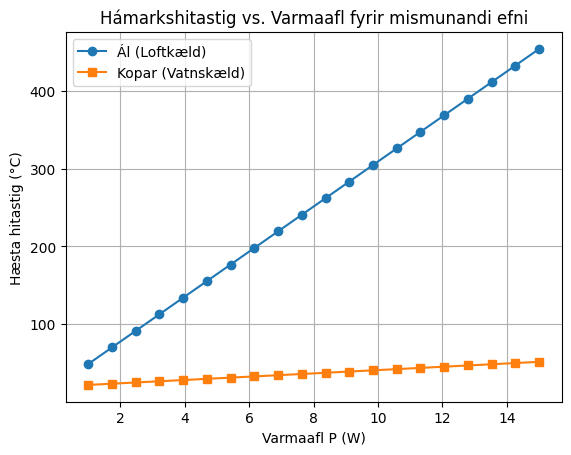

In [ ]:
def compare_materials_power():
    """
    Reiknar hæsta hitastigið fyrir tvö tilvik:
      1. Ál (air-cooled): K = 1.68, H = 0.005
      2. Kopar (water-cooled): K = 3.85, H = 0.1

    Fyrir mismunandi varmaafl (P). Graf sýnir "Hámarkshitastig vs. Afl" fyrir beggja tilvik.
    """
    # Föst gildi (sama fyrir bæði tilvik)
    Lx = 2.0      # vídd í x (cm)
    Ly = 2.0      # vídd í y (cm)
    N = 20        # netupplausn í x
    M = 20        # netupplausn í y
    L = 2.0       # lengd hitunarjaðarsvæðis (cm)
    delta = 0.1   # plötutýkkni (cm)
    ub = 20.0     # umhverfishiti (°C)

    # Efnis- og kælingastillingar:
    # Ál (air-cooled)
    K_al = 1.68   # W/(cm°C)
    H_al = 0.005  # W/(cm°C)
    # Kopar (water-cooled)
    K_cu = 3.85   # W/(cm°C)
    H_cu = 0.1    # W/(cm°C)

    # Velja bil fyrir varmaaflið P
    P_values = np.linspace(1, 15, 20)
    max_temps_al = []
    max_temps_cu = []

    # Fyrir hvert P reiknum við hæsta hitastigið með fallinu max_temperature(Lx, Ly, N, M, L, delta, P, K, H, ub)
    for P in P_values:
        Tmax_al = max_temperature(Lx, Ly, N, M, L, delta, P, K_al, H_al, ub)
        Tmax_cu = max_temperature(Lx, Ly, N, M, L, delta, P, K_cu, H_cu, ub)
        max_temps_al.append(Tmax_al)
        max_temps_cu.append(Tmax_cu)
        print(f"P = {P:5.2f} W -> Ál: {Tmax_al:6.2f} °C, Kopar: {Tmax_cu:6.2f} °C")

    # Teikna graf: hámarkhitastigið sem fall af P fyrir bæði tilvik
    plt.figure()
    plt.plot(P_values, max_temps_al, marker='o', linestyle='-', label="Ál (Loftkæld)")
    plt.plot(P_values, max_temps_cu, marker='s', linestyle='-', label="Kopar (Vatnskæld)")
    plt.xlabel("Varmaafl P (W)")
    plt.ylabel("Hæsta hitastig (°C)")
    plt.title("Hámarkshitastig vs. Varmaafl fyrir mismunandi efni")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    compare_materials_power()


# Seinni þraut

Valdir gallapunktar: [492, 1265, 1512, 611, 579, 1196, 979, 1392, 1347, 47, 1188, 1605, 295, 699, 23, 1451, 562, 918, 1047, 123]
Hæsta hitastig: 139.44 °C í (x = 0.80 cm, y = 1.75 cm)


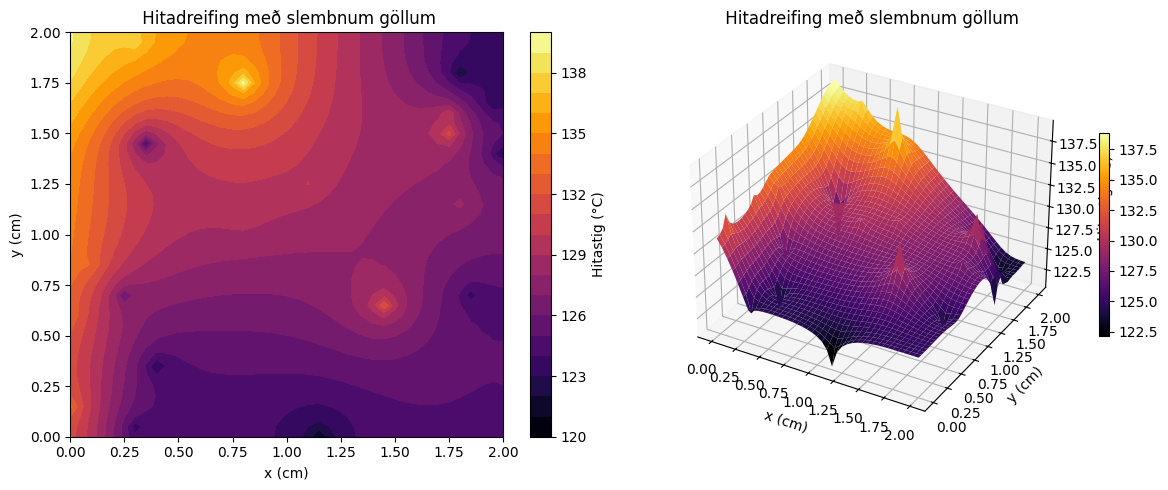

Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Fgalla: 0, Gallabil: (80, 100), Meðaltal Tmax: 164.68 °C
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Fgalla: 0, Gallabil: (100, 120), Meðaltal Tmax: 164.68 °C
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Valdir gallapunktar: []
Fgalla: 0, Gallabil: (120, 150), Meðaltal Tmax: 164.68 °C
Valdir gallapunktar: [523, 844, 1585, 557, 286]
Valdir gallapunktar: [40, 1051, 770, 929, 382]
Valdir gallapunktar: [273, 166, 574, 1140, 465]
Valdir gallapunktar: [716, 604, 1091, 180, 409]
Valdir gallapunktar: [1007, 1346, 1097, 1430, 1369]
Fgalla: 5, Gallabil: (80, 100), Meðaltal Tmax: 123.81 °C
Valdir gallapunktar: [1613, 1056, 443, 1624, 1211]
Valdir gallapunktar: [975, 1366, 898, 1341, 1142]
Valdir gallapunktar: [69, 1278, 1523, 214, 1154]
Valdir gallapunkt

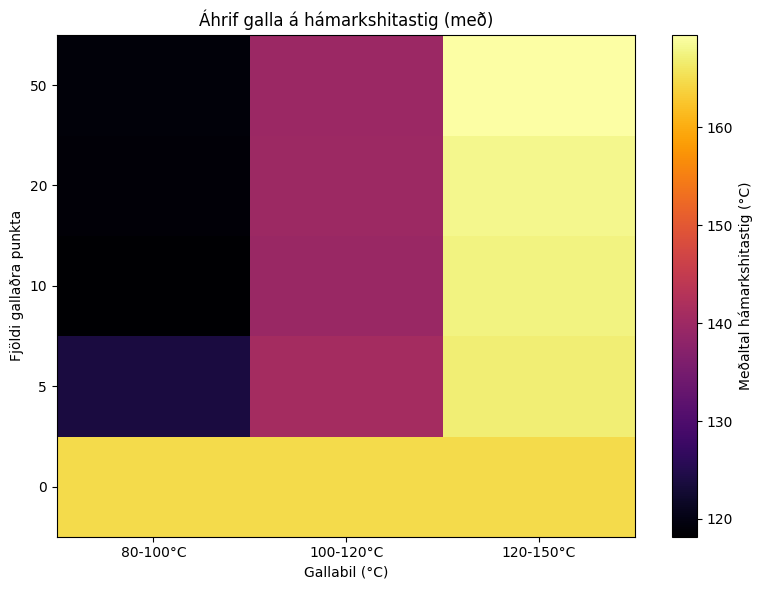

In [ ]:
# Aðal fallið fyrir gallaða varmadreifingu
def varmadreifing_faults(Lx, Ly, N, M, L, delta, P, K, H, ub, fgalla, gallabil):
    """
    Varmadreifing með slembnum göllum í netinu.

    Inntök:
    - Lx, Ly: stærð plötunnar (cm)
    - N, M: netupplausn (fjöldi punkta í x og y átt)
    - L: lengd hitunarjaðars (cm)
    - delta: þykkt plötunnar (cm)
    - P: varmaafl sem fer inn (W)
    - K: varmaleiðni efnis (W/(cm°C))
    - H: útgeislunarstuðull (W/(cm²°C))
    - ub: umhverfishitastig (°C)
    - fgalla: fjöldi punkta sem verða "gallaðir"
    - gallabil: hitastigsgildi fyrir gallaða punkta (°C) t.d. (100, 120)

    Skilar:
    - Xnet, Ynet: meshgrid fyrir teikningu
    - w: lausn fylkis (hitamunur u)
    """

    # Reiknum grunnnet og stærðir
    n = N + 1
    m = M + 1
    dx = Lx / N
    dy = Ly / M
    total_nodes = n * m

    # Reikna stuðla
    q = 2 * H / (delta * K)
    E = P / (L * delta * K)
    F = H / K

    # Búa til netið
    x = np.linspace(0, Lx, n)
    y = np.linspace(0, Ly, m)
    Xnet, Ynet = np.meshgrid(x, y)

    # Hjálparfall til að finna línulegan index
    def idx(j, k):
        return j + k * n

    # Byrjum á að setja upp fylkið A og vigurinn b
    A = sp.lil_matrix((total_nodes, total_nodes))
    b = np.zeros(total_nodes)

    # Athugar hvort punktur sé á hitunarjaðrinum
    def on_heating_boundary(k):
        y_val = k * dy
        return (Ly/2 - L/2) <= y_val <= (Ly/2 + L/2)

    # Fyllum upp í fylki A og vigur b
    for k in range(m):
        for j in range(n):
            i = idx(j, k)

            # Innri punktar
            if (j != 0) and (j != N) and (k != 0) and (k != M):
                A[i, i] = 2/dx**2 + 2/dy**2 + q
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k-1)] = -1/dy**2
                A[i, idx(j, k+1)] = -1/dy**2

            # Vinstri hornpunktur neðst
            elif j == 0 and k == 0:
                if L == Lx:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dy)
                    b[i] = 2 * E / dx
                else:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j+1, k)] = -2/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Vinstri hornpunktur efst
            elif j == 0 and k == M:
                if L == Lx:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dy)
                    b[i] = 2 * E / dx
                else:
                    A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j+1, k)] = -2/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

            # Hægri hornpunktur neðst
            elif j == N and k == 0:
                A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j-1, k)] = -2/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Hægri hornpunktur efst
            elif j == N and k == M:
                A[i, i] = 2/dx**2 + 2/dy**2 + q - 2*F/(dx + dy)
                A[i, idx(j-1, k)] = -2/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

            # Vinstri jaðar (ekki horn)
            elif j == 0:
                if on_heating_boundary(k):
                    alpha = 0.0
                    gamma = E
                else:
                    alpha = -F
                    gamma = 0.0
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dx * alpha
                A[i, idx(j+1, k)] = -2/dx**2
                if k > 0:
                    A[i, idx(j, k-1)] = -1/dy**2
                if k < m-1:
                    A[i, idx(j, k+1)] = -1/dy**2
                b[i] = 2/dx * gamma

            # Hægri jaðar (ekki horn)
            elif j == N:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dx * alpha
                A[i, idx(j-1, k)] = -2/dx**2
                if k > 0:
                    A[i, idx(j, k-1)] = -1/dy**2
                if k < m-1:
                    A[i, idx(j, k+1)] = -1/dy**2

            # Neðri jaðar (ekki horn)
            elif k == 0:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dy * alpha
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k+1)] = -2/dy**2

            # Efri jaðar (ekki horn)
            elif k == M:
                alpha = -F
                A[i, i] = 2/dx**2 + 2/dy**2 + q + 2/dy * alpha
                A[i, idx(j-1, k)] = -1/dx**2
                A[i, idx(j+1, k)] = -1/dx**2
                A[i, idx(j, k-1)] = -2/dy**2

    # Setjum inn galla í slembna punkta
    all_indices = list(range(total_nodes))
    faulty_indices = random.sample(all_indices, fgalla)
    print("Valdir gallapunktar:", faulty_indices)

    for i in faulty_indices:
        A.rows[i] = []
        A.data[i] = []
        A[i, i] = 1.0
        U_i = random.uniform(*gallabil)
        b[i] = U_i

    # Leysum jöfnuna
    A_csr = A.tocsr()
    c = spla.spsolve(A_csr, b)
    w = c.reshape((m, n))

    return Xnet, Ynet, w


# Teiknifall með bæði contour og 3D plot
def plot_results(Xnet, Ynet, w, ub, title_suffix=""):
    T = w + ub
    max_temp = np.max(T)
    idx_max = np.unravel_index(np.argmax(T), T.shape)
    print(f"Hæsta hitastig: {max_temp:.2f} °C í (x = {Xnet[idx_max]:.2f} cm, y = {Ynet[idx_max]:.2f} cm)")

    fig = plt.figure(figsize=(12, 5))

    # Contour plot
    ax1 = fig.add_subplot(1, 2, 1)
    contour = ax1.contourf(Xnet, Ynet, T, levels=20, cmap='inferno')
    ax1.set_title(f" {title_suffix}")
    ax1.set_xlabel("x (cm)")
    ax1.set_ylabel("y (cm)")
    fig.colorbar(contour, ax=ax1, label="Hitastig (°C)")

    # 3D plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax2.plot_surface(Xnet, Ynet, T, cmap='inferno', edgecolor='none')
    ax2.set_title(f" {title_suffix}")
    ax2.set_xlabel("x (cm)")
    ax2.set_ylabel("y (cm)")
    ax2.set_zlabel("Hitastig (°C)")
    fig.colorbar(surf, ax=ax2, shrink=0.5)

    plt.tight_layout()
    plt.show()



def fault_impact_study(repetitions=5):

    """
    Prófanafall til að skoða áhrif galla á hámarkshitastig.
    Keyrir fyrir mismunandi fjölda galla (fgalla) og hitabil (gallabil),
    endurtekur keyrslur til að fá meðaltal og teiknar hitakort (heatmap)
    með tölugildum inn í reitina og vistar mynd.
    """

    # Skilgreinum prófunargildi
    fgalla_values = [0, 5, 10, 20, 50]  # Fjöldi gallaðra punkta
    gallabil_values = [(80, 100), (100, 120), (120, 150)]  # Bil fyrir hitastig galla

    # Úttaksfylki til að geyma niðurstöður
    results = np.zeros((len(fgalla_values), len(gallabil_values)))

    # Lúppum yfir alla samsetningar af fjölda galla og hitabili
    for i, fgalla in enumerate(fgalla_values):
        for j, gallabil in enumerate(gallabil_values):
            max_temps = []
            for _ in range(repetitions):
                Xnet, Ynet, w = varmadreifing_faults(
                    Lx=2.0, Ly=2.0, N=40, M=40, L=2.0,
                    delta=0.1, P=5.0, K=1.68, H=0.005, ub=20.0,
                    fgalla=fgalla, gallabil=gallabil
                )
                T = w + 20.0 # Umhverfishiti lagður við
                max_temps.append(np.max(T)) # Skráum hámarkshitastig

            # Meðaltal hámarkshitastigs yfir endurtekningar
            results[i, j] = np.mean(max_temps)
            print(f"Fgalla: {fgalla}, Gallabil: {gallabil}, Meðaltal Tmax: {results[i, j]:.2f} °C")

    # Teikna hitakortið
    plt.figure(figsize=(8, 6))
    plt.imshow(results, cmap='inferno', origin='lower', aspect='auto')
    plt.colorbar(label='Meðaltal hámarkshitastig (°C)')
    plt.xticks(ticks=range(len(gallabil_values)), labels=[f"{g[0]}-{g[1]}°C" for g in gallabil_values])
    plt.yticks(ticks=range(len(fgalla_values)), labels=fgalla_values)
    plt.xlabel("Gallabil (°C)")
    plt.ylabel("Fjöldi gallaðra punkta")
    plt.title("Áhrif galla á hámarkshitastig (með)")
    plt.tight_layout()
    plt.show()


# Keyrsluforrit
if __name__ == "__main__":
    # Stök keyrsla
    Xnet, Ynet, w = varmadreifing_faults(
        Lx=2.0, Ly=2.0, N=40, M=40, L=2.0,
        delta=0.1, P=5.0, K=1.68, H=0.005, ub=20.0,
        fgalla=20, gallabil=(100, 120)
    )
    plot_results(Xnet, Ynet, w, ub=20.0, title_suffix="Hitadreifing með slembnum göllum")

    # Heildarprófun með heatmap
    fault_impact_study()